<a href="https://colab.research.google.com/github/aakarshit15/synapseCoCommLP/blob/week4/Synapse_LP_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 4**

## **DJS Synapse Learning Period**
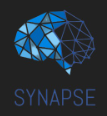

Congratulations on making it this far!! Welcome to the world of classification where we move on from unsupervised to helping the algorithms by telling them exactly what the data we're feeding them is. This week we'll be looking into  many algorithms such as Decision Trees, SVC, Naive Bayes, Random Forest and so on. We'll also be delving into hyperparameter tuning the only place where ched chaad can lead to a good result.

**Warning: This task contains many theory questions. Proceed with caution!**

Jk, make sure you research well and make sure you are understanding the models y'all are implementing as that will make your concepts much stronger and build a strong ML foundation which will be very useful as we move further with the tasks.

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

## Importing the dataset

Use this link to download the adult income dataset and upload it to your drive.

https://drive.google.com/file/d/1VAE1qF16D-sKnBOWXzGXVNGhtNZNLFQS/view?usp=sharing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
#import your dataset here
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/adult_income_dataset.csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Dealing with Nan values

In [ ]:
#write a code to find the nan values for the dataset and make a decision on whether to dropna or fill na
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


<ipython-input-5-4ff6bef9308d>:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
<ipython-input-5-4ff6bef9308d>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
<ipython-input-5-4ff6bef9308d>:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")


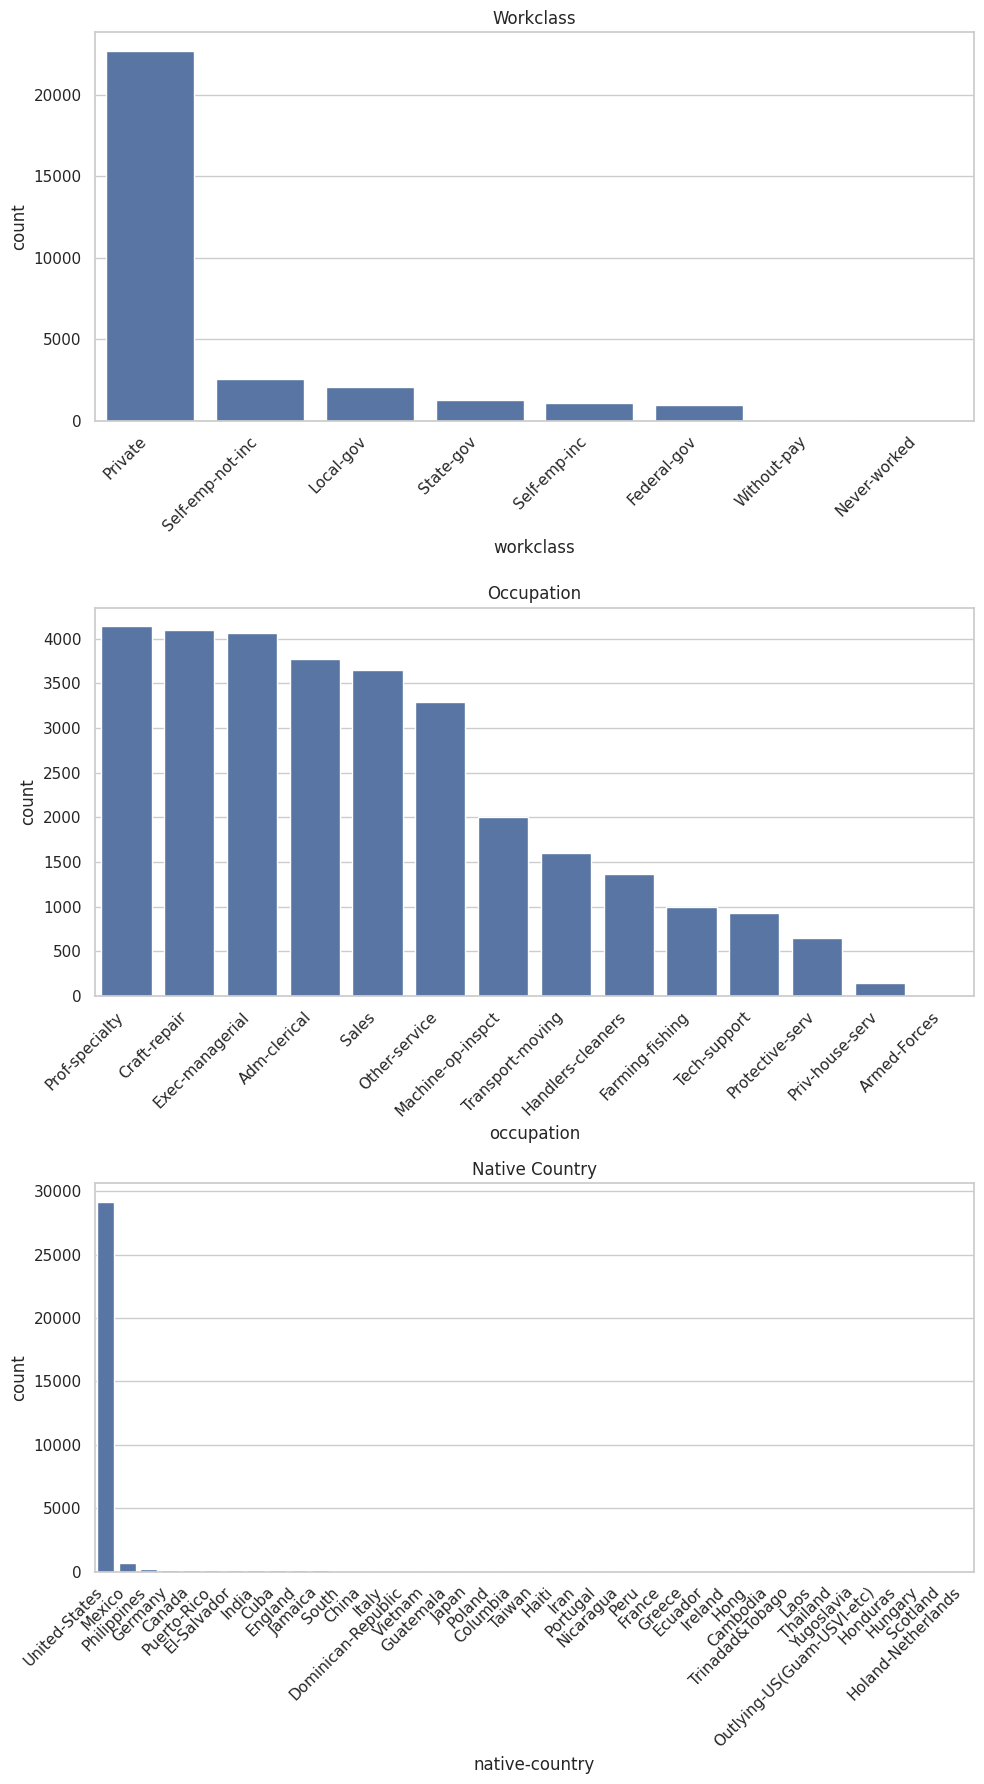

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(10, 18))

sns.countplot(ax=axes[0], data=df, x='workclass', order=df['workclass'].value_counts().index)
axes[0].set_title('Workclass')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.countplot(ax=axes[1], data=df, x='occupation', order=df['occupation'].value_counts().index)
axes[1].set_title('Occupation')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

sns.countplot(ax=axes[2], data=df, x='native-country', order=df['native-country'].value_counts().index)
axes[2].set_title('Native Country')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


In [ ]:
df["occupation"].value_counts()

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
Transport-moving,1597
Handlers-cleaners,1370


In [ ]:
df["workclass"].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df["native-country"].value_counts()

,count
native-country,
United-States,29170
Mexico,643
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [ ]:
mode_native_country = df['native-country'].mode()[0]
df['native-country'].fillna(mode_native_country, inplace=True)

In [ ]:
mode_workclass = df['workclass'].mode()[0]
df['workclass'].fillna(mode_workclass, inplace=True)

In [ ]:
most_frequent_occupation = df['occupation'].mode()[0]
df['occupation'].fillna(most_frequent_occupation, inplace=True)

In [ ]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Object Valued Columns

For Relationship, Race and Sex find out the max division average fnlwgt for each unique value.

In [ ]:
#Write your code here
relationship_avg = df.groupby('relationship')['fnlwgt'].mean()
race_avg = df.groupby('race')['fnlwgt'].mean()
sex_avg = df.groupby('sex')['fnlwgt'].mean()

max_relationship_avg = relationship_avg.idxmax(), relationship_avg.max()
max_race_avg = race_avg.idxmax(), race_avg.max()
max_sex_avg = sex_avg.idxmax(), sex_avg.max()

print(f"Max fnlwgt for Relationship: {max_relationship_avg}")
print(f"Max fnlwgt for Race: {max_race_avg}")
print(f"Max fnlwgt for Sex: {max_sex_avg}")

Max fnlwgt for Relationship: ('Other-relative', 205059.82161060142)
Max fnlwgt for Race: ('Black', 228013.1241997439)
Max fnlwgt for Sex: ('Male', 191771.44901330885)


## Getting rid of unnecessary columns

*   Drop the education num column since we already have their education in the form of categories
*   Check the combinations of the marital-status and relationship column, see if we need both of them or just marital status will work too.


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
#write your code here
df = df.drop(columns=["education-num"], axis=1)

In [ ]:
combinations = df.groupby(['marital-status', 'relationship']).size().reset_index(name='count')

print(combinations)

unique_combinations = combinations.shape[0]
print(f"Number of unique combinations between 'marital-status' and 'relationship': {unique_combinations}")

marital_status_counts = df['marital-status'].value_counts()
relationship_counts = df['relationship'].value_counts()
print(f"Marital Status Counts:\n{marital_status_counts}")
print(f"Relationship Counts:\n{relationship_counts}")

           marital-status    relationship  count
0                Divorced   Not-in-family   2404
1                Divorced  Other-relative    110
2                Divorced       Own-child    328
3                Divorced       Unmarried   1601
4       Married-AF-spouse         Husband      9
5       Married-AF-spouse  Other-relative      1
6       Married-AF-spouse       Own-child      1
7       Married-AF-spouse            Wife     12
8      Married-civ-spouse         Husband  13184
9      Married-civ-spouse   Not-in-family     17
10     Married-civ-spouse  Other-relative    124
11     Married-civ-spouse       Own-child     95
12     Married-civ-spouse            Wife   1556
13  Married-spouse-absent   Not-in-family    211
14  Married-spouse-absent  Other-relative     32
15  Married-spouse-absent       Own-child     45
16  Married-spouse-absent       Unmarried    130
17          Never-married   Not-in-family   4706
18          Never-married  Other-relative    611
19          Never-ma

In [ ]:
df = df.drop(columns=["relationship"], axis=1)

## Dealing with Categorical Data
As you probably know by now, the ML models dont know how to deal with String or object type data... so your mission shall you choose to accept it (don't really have much of a choice) is to find out which columns to do one hot encoding on and which columns to do Label Encoding on.

**Hint: Since Marital-status has less number of columns, One Hot encode it**

In [ ]:
#Write your code here
df["marital-status"].value_counts()

,count
marital-status,
Married-civ-spouse,14976
Never-married,10683
Divorced,4443
Separated,1025
Widowed,993
Married-spouse-absent,418
Married-AF-spouse,23


In [ ]:
df["education"].value_counts()

,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646


In [ ]:
df["occupation"].value_counts()

,count
occupation,
Prof-specialty,5983
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
Transport-moving,1597
Handlers-cleaners,1370


In [ ]:
df["workclass"].value_counts()

,count
workclass,
Private,24532
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df["race"].value_counts()

,count
race,
White,27816
Black,3124
Asian-Pac-Islander,1039
Amer-Indian-Eskimo,311
Other,271


In [ ]:
df["sex"].value_counts()

,count
sex,
Male,21790
Female,10771


In [ ]:
df["native-country"].value_counts()

,count
native-country,
United-States,29753
Mexico,643
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [ ]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
marital-status,object
occupation,object
race,object
sex,object
capital-gain,int64
capital-loss,int64


In [ ]:
ohe_df = df.copy()
ohe_df = pd.get_dummies(data=df, columns=["marital-status", "race", "sex"])
ohe_df.head()

,age,workclass,fnlwgt,education,occupation,capital-gain,capital-loss,hours-per-week,native-country,income,...,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,39,State-gov,77516,Bachelors,Adm-clerical,2174,0,40,United-States,<=50K,...,True,False,False,False,False,False,False,True,False,True
1,50,Self-emp-not-inc,83311,Bachelors,Exec-managerial,0,0,13,United-States,<=50K,...,False,False,False,False,False,False,False,True,False,True
2,38,Private,215646,HS-grad,Handlers-cleaners,0,0,40,United-States,<=50K,...,False,False,False,False,False,False,False,True,False,True
3,53,Private,234721,11th,Handlers-cleaners,0,0,40,United-States,<=50K,...,False,False,False,False,False,True,False,False,False,True
4,28,Private,338409,Bachelors,Prof-specialty,0,0,40,Cuba,<=50K,...,False,False,False,False,False,True,False,False,True,False


In [ ]:
from sklearn.preprocessing import LabelEncoder
e_df = ohe_df.copy()
colums = ['workclass', 'education', 'occupation', 'native-country']
le = LabelEncoder()
for col in colums:
  e_df[col + '_label'] = le.fit_transform(e_df[col])
e_df.head()

,age,workclass,fnlwgt,education,occupation,capital-gain,capital-loss,hours-per-week,native-country,income,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_label,education_label,occupation_label,native-country_label
0,39,State-gov,77516,Bachelors,Adm-clerical,2174,0,40,United-States,<=50K,...,False,False,False,True,False,True,6,9,0,38
1,50,Self-emp-not-inc,83311,Bachelors,Exec-managerial,0,0,13,United-States,<=50K,...,False,False,False,True,False,True,5,9,3,38
2,38,Private,215646,HS-grad,Handlers-cleaners,0,0,40,United-States,<=50K,...,False,False,False,True,False,True,3,11,5,38
3,53,Private,234721,11th,Handlers-cleaners,0,0,40,United-States,<=50K,...,False,True,False,False,False,True,3,1,5,38
4,28,Private,338409,Bachelors,Prof-specialty,0,0,40,Cuba,<=50K,...,False,True,False,False,True,False,3,9,9,4


## Altering the Target Column
Modify the Target Column (income) to make sure that all the values which are <=50K are replaced with a 0 and the values >50K are replaced with a 1.

In [ ]:
#write your code here
tt_df = e_df.copy()
tt_df['income'] = tt_df['income'].apply(lambda x: 0 if x == '<=50K' else 1)
tt_df

,age,workclass,fnlwgt,education,occupation,capital-gain,capital-loss,hours-per-week,native-country,income,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_label,education_label,occupation_label,native-country_label
0,39,State-gov,77516,Bachelors,Adm-clerical,2174,0,40,United-States,0,...,False,False,False,True,False,True,6,9,0,38
1,50,Self-emp-not-inc,83311,Bachelors,Exec-managerial,0,0,13,United-States,0,...,False,False,False,True,False,True,5,9,3,38
2,38,Private,215646,HS-grad,Handlers-cleaners,0,0,40,United-States,0,...,False,False,False,True,False,True,3,11,5,38
3,53,Private,234721,11th,Handlers-cleaners,0,0,40,United-States,0,...,False,True,False,False,False,True,3,1,5,38
4,28,Private,338409,Bachelors,Prof-specialty,0,0,40,Cuba,0,...,False,True,False,False,True,False,3,9,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,Tech-support,0,0,38,United-States,0,...,False,False,False,True,True,False,3,7,12,38
32557,40,Private,154374,HS-grad,Machine-op-inspct,0,0,40,United-States,1,...,False,False,False,True,False,True,3,11,6,38
32558,58,Private,151910,HS-grad,Adm-clerical,0,0,40,United-States,0,...,False,False,False,True,True,False,3,11,0,38
32559,22,Private,201490,HS-grad,Adm-clerical,0,0,20,United-States,0,...,False,False,False,True,False,True,3,11,0,38


**Extract the target column(income) and store it in a seperate variable and remove it from the original dataset. Additionally, do a 70:30 Train Test Split**

In [ ]:
tt_df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
occupation,object
capital-gain,int64
capital-loss,int64
hours-per-week,int64
native-country,object
income,int64


In [ ]:
#write your code here
X = tt_df.drop(columns=["workclass", "education", "occupation", "native-country", "income"], axis=1)
y = tt_df["income"]

In [ ]:
X

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_label,education_label,occupation_label,native-country_label
0,39,77516,2174,0,40,False,False,False,False,True,...,False,False,False,True,False,True,6,9,0,38
1,50,83311,0,0,13,False,False,True,False,False,...,False,False,False,True,False,True,5,9,3,38
2,38,215646,0,0,40,True,False,False,False,False,...,False,False,False,True,False,True,3,11,5,38
3,53,234721,0,0,40,False,False,True,False,False,...,False,True,False,False,False,True,3,1,5,38
4,28,338409,0,0,40,False,False,True,False,False,...,False,True,False,False,True,False,3,9,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,0,0,38,False,False,True,False,False,...,False,False,False,True,True,False,3,7,12,38
32557,40,154374,0,0,40,False,False,True,False,False,...,False,False,False,True,False,True,3,11,6,38
32558,58,151910,0,0,40,False,False,False,False,False,...,False,False,False,True,True,False,3,11,0,38
32559,22,201490,0,0,20,False,False,False,False,True,...,False,False,False,True,False,True,3,11,0,38


In [ ]:
y

,income
0,0
1,0
2,0
3,0
4,0
...,...
32556,0
32557,1
32558,0
32559,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(22792, 23)
(9769, 23)
(22792,)
(9769,)


### Chalo now that we have the preprocessed data we can feed it into the models. Lets start with some basic ones.

# Logistic Regression
*   Theory:https://www.youtube.com/watch?v=yIYKR4sgzI8&list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe
*   Implementation: https://www.youtube.com/watch?v=n40hS9tQmcY


Explain the algorithm, its working and its use cases.

In [ ]:
#import the model and apply it to the data
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
classifier = LogisticRegression()
parameters={"penalty":['l1', 'l2', 'elasticnet'], 'C':[1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50], 'max_iter': [500, 600, 700, 800, 900, 1000]}

In [ ]:
classifier_regressor = GridSearchCV(classifier, param_grid=parameters, scoring='accuracy', cv=5)

In [ ]:
classifier_regressor.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
660 fits failed out of a total of 990.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
330 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1169, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50],
                         'max_iter': [500, 600, 700, 800, 900, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy')

In [ ]:
classifier_regressor.best_params_

{'C': 5, 'max_iter': 500, 'penalty': 'l2'}

In [ ]:
classifier_regressor.best_score_

0.7929094344049992

In [ ]:
y_pred_logi = classifier_regressor.predict(X_test)

In [ ]:
logi_acc = accuracy_score(y_pred_logi, y_test)
print(logi_acc)
print(confusion_matrix(y_test, y_pred_logi))
print(classification_report(y_test, y_pred_logi))

0.7907667110246699
[[7040  371]
 [1673  685]]
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      7411
           1       0.65      0.29      0.40      2358

    accuracy                           0.79      9769
   macro avg       0.73      0.62      0.64      9769
weighted avg       0.77      0.79      0.76      9769



Find the accuracy and confusion matrix for the same and explain what it shows.

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [ ]:
#import the model from sklearn and apply it to your data
from sklearn.naive_bayes import GaussianNB

In [ ]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred_naive = gnb.predict(X_test)

naive_acc = accuracy_score(y_test, y_pred_naive)
print(f"Accuracy: {naive_acc:.2f}")
print(confusion_matrix(y_test, y_pred_naive))
print(classification_report(y_test, y_pred_naive))

Accuracy: 0.80
[[7034  377]
 [1610  748]]
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      7411
           1       0.66      0.32      0.43      2358

    accuracy                           0.80      9769
   macro avg       0.74      0.63      0.65      9769
weighted avg       0.78      0.80      0.77      9769



# Decision Tree Classifier
* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

In [ ]:
#import the decision tree from sklearn and run it on your data
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt_model.predict(X_test)

<b>Print the Model Accuracy</b>

In [ ]:
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {dt_acc:.2f}")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.81
[[6467  944]
 [ 910 1448]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      7411
           1       0.61      0.61      0.61      2358

    accuracy                           0.81      9769
   macro avg       0.74      0.74      0.74      9769
weighted avg       0.81      0.81      0.81      9769



## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans:

**Logistic Regression**

Logistic Regression is a linear model used for binary classification. It models the probability of an outcome using a logistic function (sigmoid) to convert linear combinations of input features into probabilities.

The decision boundary is linear. It tries to separate the classes by fitting a straight line (or plane) in feature space.

Logistic regression assumes that the relationship between the features and the log-odds of the outcome is linear.

**Naive Bayes**

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It calculates the probability of a class given the input features.

The model makes the naive assumption that all features are independent of each other, which is rarely true in real-world datasets.

Naive Bayes calculates probabilities based on the assumption that the presence (or absence) of one feature does not influence the others.

**Decision Tree**

A Decision Tree is a non-parametric model that splits the dataset into subsets based on feature values. It creates a tree-like structure where internal nodes represent conditions on features, branches represent the outcomes of the conditions, and leaf nodes represent class labels.

The tree splits recursively based on a criterion such as Gini impurity or information gain until the data is fully classified or a stopping criterion (e.g., depth) is met.

Decision Trees can capture non-linear relationships because they create decision boundaries that are more flexible than those of linear models.


### Mention some real life use cases for each of these three models:

Ans:

**Logistic Regression** => Medical analysis, Credit Scoring, Loan Default Prediction, Customer Churn Prediction, Marketing and Lead Conversion.

**Naive Bayes** => Spam Detection, Sentimental Analysis, Document Classificaton

**Decision Tree** => Fraud Detection, Employee Attrition Prediction, Fraud Detection

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

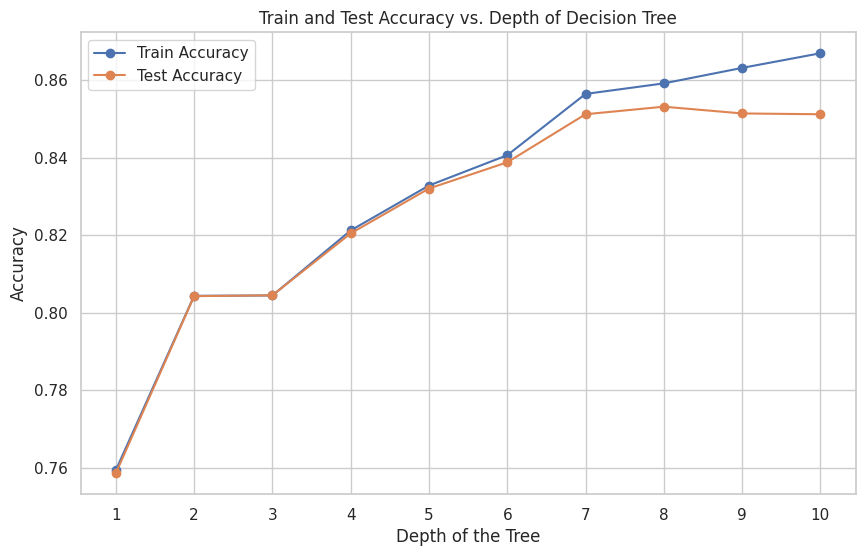

In [ ]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)

train_accuracies = []
test_accuracies = []

depths = range(1, 11)

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='o')
plt.title('Train and Test Accuracy vs. Depth of Decision Tree')
plt.xlabel('Depth of the Tree')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn import tree
!pip install graphviz

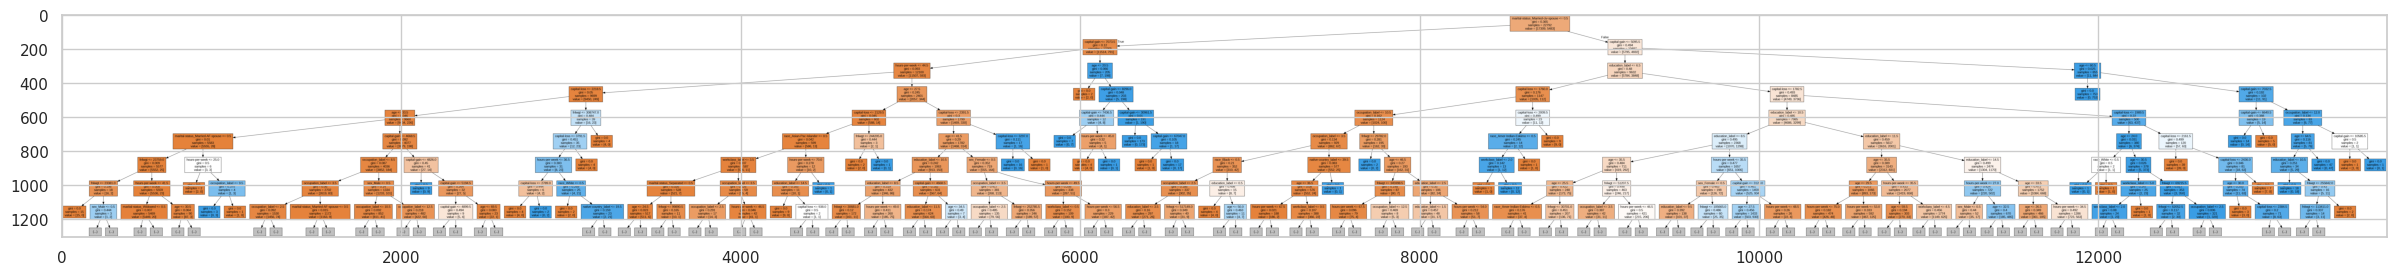

In [ ]:
#complete the code below to create an image of the decision tree
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz(dt_model, out_file='tree.dot', feature_names=X_train.columns, max_depth=8, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file
image = plt.imread('tree.png')
plt.figure(figsize=(30,30))
plt.imshow(image)

<b>print the test accuracy and train accuracy here</b>

In [ ]:
#write code here


In [ ]:
import itertools

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import itertools

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logistic_params = [
    {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [100, 200, 300], 'penalty': ['l1', 'l2'], 'class_weight': ['balanced', None]},
    {'C': [0.01, 0.1, 1, 10], 'solver': ['newton-cg', 'lbfgs', 'saga'], 'max_iter': [100, 200, 300], 'penalty': ['l2', 'none'], 'class_weight': ['balanced', None]},
    {'C': [0.01, 0.1, 1, 10], 'solver': ['saga'], 'max_iter': [100, 200, 300], 'penalty': ['elasticnet'], 'class_weight': ['balanced', None]}
]

nb_params = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

tree_params = {'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
                'max_features': [None, 'sqrt', 'log2']}

def train_and_evaluate(model, param_grids, X_train, y_train, X_test, y_test):
    best_score = 0
    best_params = {}

    for params in param_grids:
        model.set_params(**params)
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            score = accuracy_score(y_test, y_pred)

            if score > best_score:
                best_score = score
                best_params = params
        except ValueError as e:
            print(f"Skipping parameters {params} due to error: {e}")

    return best_score, best_params

logistic_params_list = [dict(zip(param_grid.keys(), v)) for param_grid in logistic_params for v in itertools.product(*param_grid.values())]
logistic_model = LogisticRegression()
logistic_best_score, logistic_best_params = train_and_evaluate(logistic_model, logistic_params_list, X_train, y_train, X_test, y_test)
print(f"Best Logistic Regression Score: {logistic_best_score}\nBest Parameters: {logistic_best_params}")

nb_params_list = [dict(zip(nb_params, [v])) for v in nb_params['var_smoothing']]
nb_model = GaussianNB()
nb_best_score, nb_best_params = train_and_evaluate(nb_model, nb_params_list, X_train, y_train, X_test, y_test)
print(f"Best Gaussian Naive Bayes Score: {nb_best_score}\nBest Parameters: {nb_best_params}")

tree_params_list = [dict(zip(tree_params, v)) for v in itertools.product(*tree_params.values())]
tree_model = DecisionTreeClassifier()
tree_best_score, tree_best_params = train_and_evaluate(tree_model, tree_params_list, X_train, y_train, X_test, y_test)
print(f"Best Decision Tree Score: {tree_best_score}\nBest Parameters: {tree_best_params}")


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour

Skipping parameters {'C': 0.01, 'solver': 'saga', 'max_iter': 100, 'penalty': 'elasticnet', 'class_weight': 'balanced'} due to error: l1_ratio must be specified when penalty is elasticnet.
Skipping parameters {'C': 0.01, 'solver': 'saga', 'max_iter': 100, 'penalty': 'elasticnet', 'class_weight': None} due to error: l1_ratio must be specified when penalty is elasticnet.
Skipping parameters {'C': 0.01, 'solver': 'saga', 'max_iter': 200, 'penalty': 'elasticnet', 'class_weight': 'balanced'} due to error: l1_ratio must be specified when penalty is elasticnet.
Skipping parameters {'C': 0.01, 'solver': 'saga', 'max_iter': 200, 'penalty': 'elasticnet', 'class_weight': None} due to error: l1_ratio must be specified when penalty is elasticnet.
Skipping parameters {'C': 0.01, 'solver': 'saga', 'max_iter': 300, 'penalty': 'elasticnet', 'class_weight': 'balanced'} due to error: l1_ratio must be specified when penalty is elasticnet.
Skipping parameters {'C': 0.01, 'solver': 'saga', 'max_iter': 300, 

### Explain the different hyperparameters you changed and how did it affect the models. Also give a summary of the graphs you made.

Ans:

1. **Logistic Regression: **

*C*: This controls the regularization strength (inverse of regularization). Smaller values of C imply stronger regularization, helping to prevent overfitting but may underfit the data. Larger values of C reduce regularization, allowing the model more freedom to fit the training data, but at the risk of overfitting. Smaller C values tend to produce simpler models with higher bias, while larger C values reduce bias but increase variance.

*solver*: Specifies the algorithm to use for optimization. Different solvers handle optimization differently.

liblinear is suitable for small datasets and performs well with L1 regularization.

newton-cg, lbfgs, saga is suitable for larger datasets and multi-class classification. The saga solver is the only one that supports elasticnet.

The choice of solver affects convergence speed and whether certain penalties like l1, l2, or elasticnet can be used. For example, liblinear is better for sparse data, but saga works with elasticnet regularization.

*penalty* specifies the norm for penalizing model complexity. Different penalties are used for regularization:

l1: Lasso regularization, which can result in sparse models where some coefficients are zero.

l2: Ridge regularization, which shrinks coefficients but usually keeps them non-zero.

elasticnet: A combination of L1 and L2 regularization, offering a balance between sparse and non-sparse models.

none: No regularization.

L1 can help with feature selection by eliminating irrelevant features (setting their coefficients to zero). L2 is more about shrinking large coefficients and preventing overfitting. ElasticNet offers a mix of both.

*max_iter*: The maximum number of iterations for the solver to converge.
If set too low, the model may not converge, resulting in suboptimal coefficients. Increasing max_iter allows the solver more time to find the optimal solution.

*class_weight*: Controls the weight assigned to different classes.

balanced: Adjusts weights inversely proportional to class frequencies to handle imbalanced datasets.

It can improve model performance on imbalanced datasets by giving more weight to the minority class.


**Gaussian Naive Bayes**

Gaussian Naive Bayes is a relatively simple model, and we only varied one hyperparameter:

var_smoothing: This adds a small value to the variance of each feature to avoid division by zero in cases where a feature has zero variance.

Increasing var_smoothing makes the model more tolerant of noisy or small data variance. It can help prevent overfitting on very small datasets or features that have little variance.

**Decision Tree Classifier**

*criterion*: This controls how the quality of a split is measured.

gini: Measures the impurity of a node.
entropy: Uses information gain for the split.
Both are used to create splits that maximize information gain or reduce impurity. The difference is usually minor, but entropy may result in slightly more balanced trees.

*max_depth*: The maximum depth of the tree.
Controls how deep the tree can grow. Smaller values prevent the tree from growing too deep (avoiding overfitting) but may result in underfitting if set too low. Larger values allow the tree to grow deeper, potentially leading to overfitting if the model fits too closely to the training data.

*min_samples_split*: The minimum number of samples required to split an internal node. Higher values prevent splitting nodes with fewer samples, making the tree simpler (higher bias) but reducing overfitting. Lower values result in more splits, increasing model complexity and potentially overfitting.

*min_samples_leaf*: The minimum number of samples required to be at a leaf node.
Larger values produce trees with larger leaves (more samples per leaf), which can help prevent overfitting by smoothing the model. Smaller values may result in highly specific splits, leading to overfitting.

*max_features*: The number of features to consider when looking for the best split.
None: Use all features.
sqrt: Use the square root of the number of features.
log2: Use the logarithm base 2 of the number of features.
Limiting the number of features considered at each split reduces overfitting and variance but may increase bias.

## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [ ]:
#implement Random forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
#find the accuracy
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 86.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7428
           1       0.75      0.61      0.67      2341

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



### Explain the difference between random forest and decision tree. Also think of cases where the outputs for both of them can be same if its possible.

Ans:

**Descision Tree**

A Decision Tree builds a single tree by recursively splitting the data based on the features. The splits are made to optimize a criterion such as Gini impurity or information gain.

Decision Trees can easily overfit the training data, especially if they are allowed to grow deep. This can result in high variance, meaning the model may perform well on the training data but poorly on unseen data.

Decision Trees are highly interpretable because they are easy to visualize, and the decision-making process can be traced by following the tree from the root to a leaf node.

**Random Forest**

A Random Forest is an ensemble of multiple Decision Trees. Instead of relying on a single tree, it builds many trees (typically hundreds or thousands) using bootstrap sampling (random subsets of the data) and random feature selection at each split.

The final prediction is made by averaging the predictions of all the trees (in case of regression) or by taking a majority vote (in case of classification). This helps reduce the risk of overfitting.

In Random Forest, not only is the data sampled, but at each node, only a random subset of features is considered for splitting. This makes the trees more diverse and less likely to overfit to specific patterns in the data.

Due to the large number of trees, Random Forests are more difficult to interpret compared to a single Decision Tree.

If the data is simple, with clear linear separability or obvious decision boundaries, a single Decision Tree may find an optimal split that performs well on both training and test data. In this case, adding more trees in Random Forest may not offer much improvement, and the predictions from both models could be the same.



In [ ]:
#write a code to implement BaggingClassifier

### Explain how are Bagging and Random Forest different and why do we do bagging?


Ans:

**Bagging**

Bagging is a technique that aims to reduce the variance of machine learning models, especially high-variance models like decision trees. The idea is to create multiple models (often decision trees) and train each one on a random sample (with replacement) of the training data, a process known as bootstrap sampling.

**Random Forest**

Random Forest is a specific application of Bagging, but with an additional layer of randomness. Like Bagging, it trains multiple decision trees using bootstrap samples of the data, but it introduces randomness in the feature selection as well.

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
*   Theory:https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [ ]:
#write code here
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
y_pred_ada = ada_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_ada)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

Accuracy: 86.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      7428
           1       0.77      0.61      0.68      2341

    accuracy                           0.86      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



Just to make things more interesting implement XGBoost as well and compare its accuracy with that of AdaBoost :)

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:21:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb * 100:.2f}%")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 87.24%

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7428
           1       0.77      0.66      0.71      2341

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



In [ ]:
if accuracy_xgb > accuracy:
    print(f"\nXGBoost outperforms AdaBoost by {accuracy_xgb - accuracy:.2f}%")
else:
    print(f"\nAdaBoost outperforms XGBoost by {accuracy - accuracy_xgb:.2f}%")


XGBoost outperforms AdaBoost by 0.01%


### Explain: What is the difference between Adaboost and XGBoost. Also describe in what cases is XGBoost better to use than AdaBoost.

Ans:

**Adaboost**

AdaBoost works by training weak learners sequentially, typically decision stumps (one-level decision trees). It assigns weights to each instance in the training data, starting with equal weights. After each model is trained, AdaBoost increases the weights of misclassified instances, forcing the next model to focus more on the harder examples. This process continues iteratively, and the final prediction is a weighted sum of all the weak learners' predictions.

**XGBoost**

XGBoost is an advanced version of gradient boosting that uses decision trees as base learners. It builds trees sequentially, where each tree tries to correct the errors made by the previous one, but it does this in a more sophisticated way than AdaBoost. It minimizes a loss function (such as log loss for classification) using gradient descent, hence the name "gradient boosting."

## Explain: What is the difference between Bagging and Boosting? Explain with examples

Ans:

### 3. Pruning Techniques



*   Theory: https://opendatascience.com/what-is-pruning-in-machine-learning/
*   Theory:https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107



In [ ]:
#implement pruning
base_estimator_pruned = DecisionTreeClassifier(max_depth=3, min_samples_split=20, min_samples_leaf=10)

In [ ]:
ada_model_pruned = AdaBoostClassifier(base_estimator=base_estimator_pruned, n_estimators=100, random_state=42)
ada_model_pruned.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         min_samples_leaf=10,
                                                         min_samples_split=20),
                   n_estimators=100, random_state=42)

In [ ]:
rf_model_pruned = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_split=20, min_samples_leaf=10, random_state=42)
rf_model_pruned.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred_ada_pruned = ada_model_pruned.predict(X_test)
y_pred_rf_pruned = rf_model_pruned.predict(X_test)

In [ ]:
accuracy_ada_pruned = accuracy_score(y_test, y_pred_ada_pruned)
print(f"Pruned AdaBoost Accuracy: {accuracy_ada_pruned * 100:.2f}%")
print("\nPruned AdaBoost Classification Report:")
print(classification_report(y_test, y_pred_ada_pruned))

Pruned AdaBoost Accuracy: 86.14%

Pruned AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7428
           1       0.74      0.65      0.69      2341

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [ ]:
accuracy_rf_pruned = accuracy_score(y_test, y_pred_rf_pruned)
print(f"Pruned Random Forest Accuracy: {accuracy_rf_pruned * 100:.2f}%")
print("\nPruned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_pruned))


Pruned Random Forest Accuracy: 83.38%

Pruned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      7428
           1       0.91      0.34      0.50      2341

    accuracy                           0.83      9769
   macro avg       0.87      0.66      0.70      9769
weighted avg       0.85      0.83      0.80      9769



In [ ]:
if accuracy_rf_pruned > accuracy_ada_pruned:
    print(f"\nPruned Random Forest outperforms Pruned AdaBoost by {accuracy_rf_pruned - accuracy_ada_pruned:.2f}%")
else:
    print(f"\nPruned AdaBoost outperforms Pruned Random Forest by {accuracy_ada_pruned - accuracy_rf_pruned:.2f}%")


Pruned AdaBoost outperforms Pruned Random Forest by 0.03%


In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique
pruned_tree = DecisionTreeClassifier(max_depth=3, min_samples_split=20, min_samples_leaf=10, random_state=42)
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
from IPython.display import Image
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [ ]:
dot_data = export_graphviz(pruned_tree, out_file=None,
                           feature_names=X.columns,
                           class_names=['less_than_50K', 'greater_than_50K'],
                           filled=True, rounded=True,
                           special_characters=True)

In [ ]:
graph = graphviz.Source(dot_data)
graph.render("pruned_tree")

'pruned_tree.pdf'

In [ ]:
graph.view()

'pruned_tree.pdf'

In [ ]:
#write your code here

<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

As a brush up on data visualisation... make a graph to compare the accuracies you achieved for each of the models you trained and explain which one is the best to perform classification tasks and why?

In [ ]:
#write your code here
accuracies = {
    'Random Forest': accuracy_rf,
    'AdaBoost': accuracy,
    'XGBoost': accuracy_xgb
}

In [ ]:
import seaborn as sns

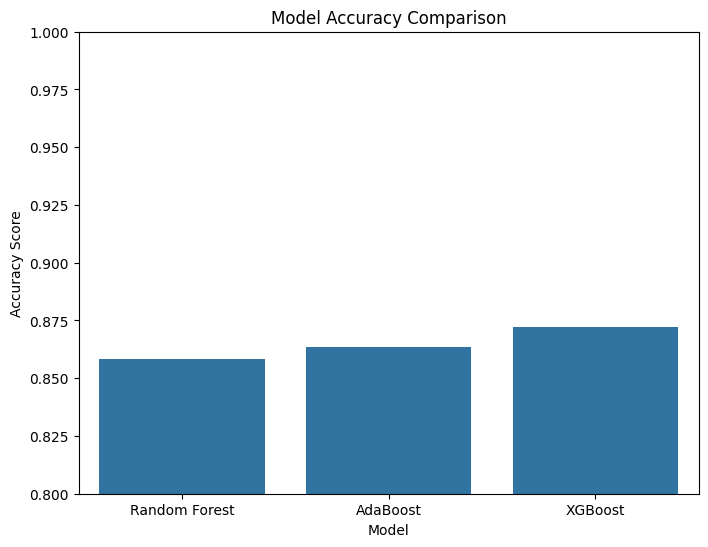

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.ylim(0.8, 1.0)  # Set the range of y-axis to focus on high accuracy
plt.show()

# **Bonus: To be done only if you have completed the above tasks.**

Ensemble Models are not only used for classification but also for Regression.Research on the various regression models such as XGBoost Regressor and Random Forest regressor and how are they different from the Linear Regression model we made in Task 2. The best research will be edited and featured on the Synapse Instagram page. Happy coding! :)

**XGBoost**

A boosting algorithm that builds models sequentially. Each new model corrects the errors made by the previous ones.Builds a series of decision trees, where each new tree focuses on the residuals (errors) of the previous trees.
It minimizes a loss function using a gradient descent approach, ensuring that each new model improves the overall prediction.

**Random Forest Regressor**

An ensemble model that builds multiple decision trees and averages their predictions. It constructs multiple decision trees (using different random subsets of data and features) and combines their predictions through averaging (in regression). Trees are built by recursively splitting data points based on feature values that minimize the residual sum of squares.

**Linear Regression**

A simple and interpretable model.It assumes a linear relationship between input features (independent variables) and the target (dependent variable). It fits a straight line (or hyperplane in multiple dimensions) that minimizes the error, typically using the ordinary least squares (OLS) method.

# **End of Task**

> ©DJS Synapse 2024 - 2025